# [Lab 5-2] Variational Autoencoder (VAE)를 활용한 잠재 공간 매니폴드 생성 실습

본 실습에서는 단순한 압축/복원을 넘어 **새로운 데이터를 생성(Generation)**할 수 있는 대표적인 심층 확률적 생성 모델인 **Variational Autoencoder (VAE)**의 이론적 원리와 아키텍처를 배우고 직접 구현합니다.

---

### 💡 Autoencoder vs Variational Autoencoder (VAE)
| 구분 | 일반 Autoencoder (AE) | Variational Autoencoder (VAE) |
|---|---|---|
| **잠재 공간 (Latent Space)** | 고정된 결정론적 점 (Deterministic Vector) | **확률 분포 (평균 $\mu$, 분산 $\sigma^2$)** |
| **잠재 공간 분포** | 불연속적이고 빈 공간(Hole) 존재 | **표준 정규분포 $\mathcal{N}(0, I)$로 정렬 및 연속성 확보** |
| **주요 목적** | 차원 축소, 압축, 노이즈 제거, 이상 탐지 | **새로운 데이터 생성 (Generative Modeling)**, 매니폴드 보간 |

---

### 📐 VAE의 3대 핵심 메커니즘
1. **확률적 인코더 (Probabilistic Encoder)**:
   - 입력 $x$로부터 하나의 잠재 벡터가 아닌, 잠재 변수의 **평균 벡터 $\mu$**와 **로그 분산 벡터 $\log(\sigma^2)$**를 추정합니다.
2. **재매개변수화 트릭 (Reparameterization Trick)**:
   - 확률적 샘플링($z \sim \mathcal{N}(\mu, \sigma^2)$) 노드는 미분이 불가능하여 오차 역전파(Backpropagation)가 불가능합니다.
   - 외부 표준 정규 난수 $\epsilon \sim \mathcal{N}(0, I)$를 도입하여 **$z = \mu + \sigma \odot \epsilon$** 형태로 분리함으로써 역전파가 가능하도록 만듭니다.
3. **ELBO 손실 함수 (Evidence Lower Bound)**:
   $$\text{Total Loss} = \text{Reconstruction Loss} + D_{KL}(q(z|x) \,||\, p(z))$$
   - **재구성 손실 (Reconstruction Loss)**: 원본 $x$를 얼마나 정밀하게 복원했는가 (Binary Cross-Entropy)
   - **KL 발산 손실 (KL Divergence Loss)**: 잠재 공간의 분포가 표준 정규분포 $\mathcal{N}(0, I)$와 얼마나 유사하게 정렬되었는가

In [1]:
# 라이브러리 임포트 및 시각화 설정
import numpy as np
import matplotlib.pyplot as plt

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"   # GPU 사용 안함

import tensorflow as tf
from tensorflow.keras import layers, models

# 한글 폰트 및 마이너스 부호 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"TensorFlow 버전: {tf.__version__}")

TensorFlow 버전: 2.10.1


## 1. 데이터 준비 (MNIST)

손글씨 숫자 이미지(MNIST)를 로드하고, 픽셀값을 $[0, 1]$ 범위로 정규화합니다.
합성곱 신경망 처리를 위해 `(28, 28, 1)` 크기의 4차원 텐서로 변환합니다.

In [4]:
# MNIST 데이터셋 로드
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 0~1 정규화 및 차원 확장
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"훈련 데이터 형태: {x_train.shape}")
print(f"테스트 데이터 형태: {x_test.shape}")

훈련 데이터 형태: (60000, 28, 28, 1)
테스트 데이터 형태: (10000, 28, 28, 1)


## 2. VAE 아키텍처 설계

### 2.1 Reparameterization Layer (재매개변수화 트릭 계층)
평균($\mu$)과 로그 분산($\log \sigma^2$)을 입력받아 다음과 같이 잠재 벡터 $z$를 샘플링합니다:
$$z = \mu + e^{0.5 \cdot \log(\sigma^2)} \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

In [5]:
class Sampling(layers.Layer):
    # Reparameterization Trick을 구현하는 커스텀 레이어
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        # 표준 정규분포에서 입실론(epsilon) 샘플링
        epsilon = tf.random.normal(shape=(batch, dim))
        # z = mu + sigma * epsilon (sigma = exp(0.5 * log_var))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

### 2.2 인코더(Encoder)와 디코더(Decoder) 정의
2차원 평면에서의 직관적인 시각화를 위해 잠재 공간의 차원 수(`latent_dim`)를 **2**로 설정합니다.

In [6]:
latent_dim = 2

# [1. Encoder 정의]
encoder_inputs = layers.Input(shape=(28, 28, 1), name="encoder_input")
x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_inputs)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

# 평균(mu)과 로그 분산(log_var) 출력 노드
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# 재매개변수화 트릭을 통한 잠재 벡터 z 샘플링
z = Sampling()([z_mean, z_log_var])

encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 28, 28, 1)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 14, 14, 32)   320         ['encoder_input[0][0]']          
                                                                                                  
 conv2d_1 (Conv2D)              (None, 7, 7, 64)     18496       ['conv2d[0][0]']                 
                                                                                                  
 flatten (Flatten)              (None, 3136)         0           ['conv2d_1[0][0]']               
                                                                                            

In [7]:
# [2. Decoder 정의]
latent_inputs = layers.Input(shape=(latent_dim,), name="decoder_input")
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
decoder_outputs = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(x)

decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 decoder_input (InputLayer)  [(None, 2)]               0         
                                                                 
 dense_1 (Dense)             (None, 3136)              9408      
                                                                 
 reshape (Reshape)           (None, 7, 7, 64)          0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 14, 14, 64)       36928     
 nspose)                                                         
                                                                 
 conv2d_transpose_1 (Conv2DT  (None, 28, 28, 32)       18464     
 ranspose)                                                       
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 1)         289 

## 3. VAE 모델 클래스 및 손실 함수(ELBO) 구현

Keras `Model` 클래스를 상속받아 `train_step`에서 Reconstruction Loss와 KL Divergence Loss를 합산하여 역전파를 수행하도록 구현합니다.
- **재구성 손실 (Reconstruction Loss)**:
  $$\text{Reconstruction Loss} = \sum_{pixels} \text{Binary Cross-Entropy}(x, \hat{x})$$
- **KL 발산 손실 (KL Divergence Loss)**:
  $$D_{KL} = -\frac{1}{2} \sum \left( 1 + \log(\sigma^2) - \mu^2 - e^{\log(\sigma^2)} \right)$$

In [8]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        # 손실 추적을 위한 Metric 객체들
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # 1. 인코딩: z_mean, z_log_var, z 샘플링
            z_mean, z_log_var, z = self.encoder(data)
            # 2. 디코딩: 원본 복원
            reconstruction = self.decoder(z)
            
            # 3. 재구성 손실 (픽셀별 BCE 합의 배치 평균)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )
            
            # 4. KL Divergence 손실 (정규분포와의 차이)
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )
            
            # 5. 최종 ELBO 손실
            total_loss = reconstruction_loss + kl_loss

        # 6. 역전파 및 가중치 업데이트
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # 메트릭 업데이트
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

## 4. VAE 모델 학습 실행

In [9]:
# VAE 인스턴스 생성 및 컴파일
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# 모델 학습 (20 에포크)
history = vae.fit(
    x_train,
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
469/469 [==============================] - 69s 145ms/step - loss: 267.9748 - reconstruction_loss: 214.1020 - kl_loss: 3.3942
Epoch 2/20
469/469 [==============================] - 69s 146ms/step - loss: 191.3912 - reconstruction_loss: 186.6768 - kl_loss: 3.4415
Epoch 3/20
469/469 [==============================] - 66s 141ms/step - loss: 186.0169 - reconstruction_loss: 182.1252 - kl_loss: 3.5023
Epoch 4/20
469/469 [==============================] - 71s 151ms/step - loss: 182.0923 - reconstruction_loss: 173.7428 - kl_loss: 4.5009
Epoch 5/20
469/469 [==============================] - 71s 152ms/step - loss: 167.9019 - reconstruction_loss: 161.1821 - kl_loss: 5.8882
Epoch 6/20
469/469 [==============================] - 72s 154ms/step - loss: 164.2198 - reconstruction_loss: 157.6048 - kl_loss: 6.1453
Epoch 7/20
469/469 [==============================] - 73s 155ms/step - loss: 162.2118 - reconstruction_loss: 155.7305 - kl_loss: 6.2142
Epoch 8/20
469/469 [============================

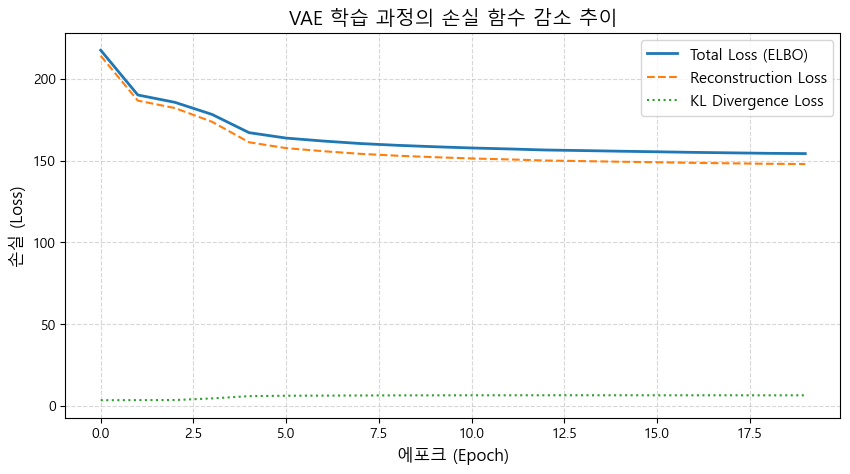

In [10]:
# 학습 손실 추이 시각화
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Total Loss (ELBO)", linewidth=2)
plt.plot(history.history["reconstruction_loss"], label="Reconstruction Loss", linestyle="--")
plt.plot(history.history["kl_loss"], label="KL Divergence Loss", linestyle=":")
plt.title("VAE 학습 과정의 손실 함수 감소 추이", fontsize=14)
plt.xlabel("에포크 (Epoch)", fontsize=12)
plt.ylabel("손실 (Loss)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 5. 2차원 잠재 공간(Latent Space) 시각화

테스트셋 이미지들을 인코더에 통과시켜 얻은 잠재 변수의 평균값 $(\mu_1, \mu_2)$을 2차원 평면에 산점도로 그립니다.
- VAE의 KL Divergence 손실 덕분에 잠재 공간의 모든 숫자들이 **원점 $(0, 0)$을 중심으로 표준 정규분포 형태로 연속적으로 매끄럽게 배치**되어 있음을 확인할 수 있습니다.

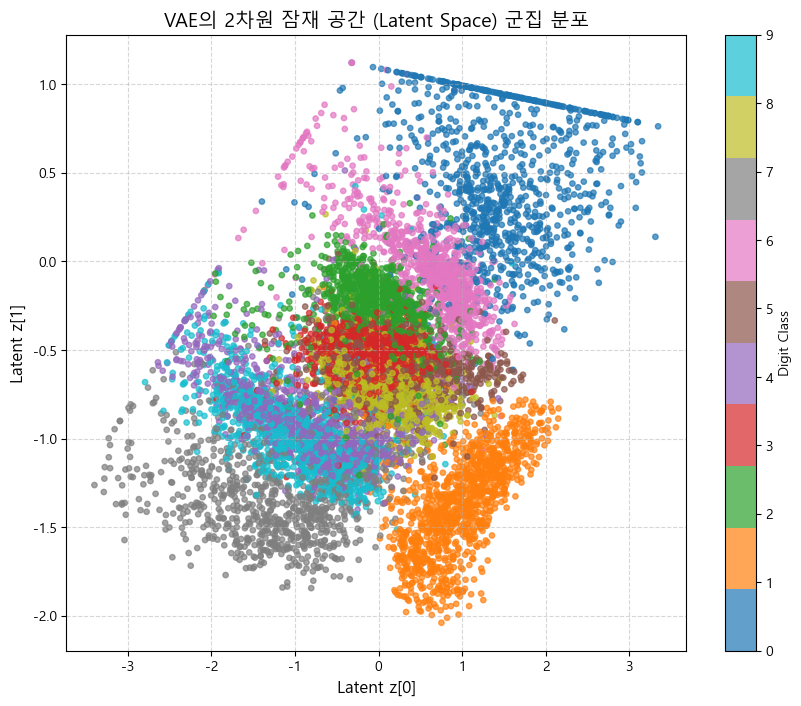

In [11]:
# 테스트 데이터 인코딩
z_mean, _, _ = vae.encoder.predict(x_test, verbose=0)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test, cmap="tab10", alpha=0.7, s=15)
plt.colorbar(scatter, ticks=range(10), label="Digit Class")
plt.xlabel("Latent z[0]", fontsize=12)
plt.ylabel("Latent z[1]", fontsize=12)
plt.title("VAE의 2차원 잠재 공간 (Latent Space) 군집 분포", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 6. 잠재 공간 매니폴드 탐색 (2D Latent Manifold Image Generation)

2차원 잠재 평면에서 $z_1 \in [-3, 3]$과 $z_2 \in [-3, 3]$ 범위의 균등 격자 좌표를 생성하여 디코더에 입력합니다.
- 잠재 공간의 좌표가 연속적으로 이동함에 따라, **숫자 형태가 부드럽게 변형(Interpolation/Morphing)되며 새로운 손글씨가 생성되는 과정**을 한눈에 확인할 수 있습니다!

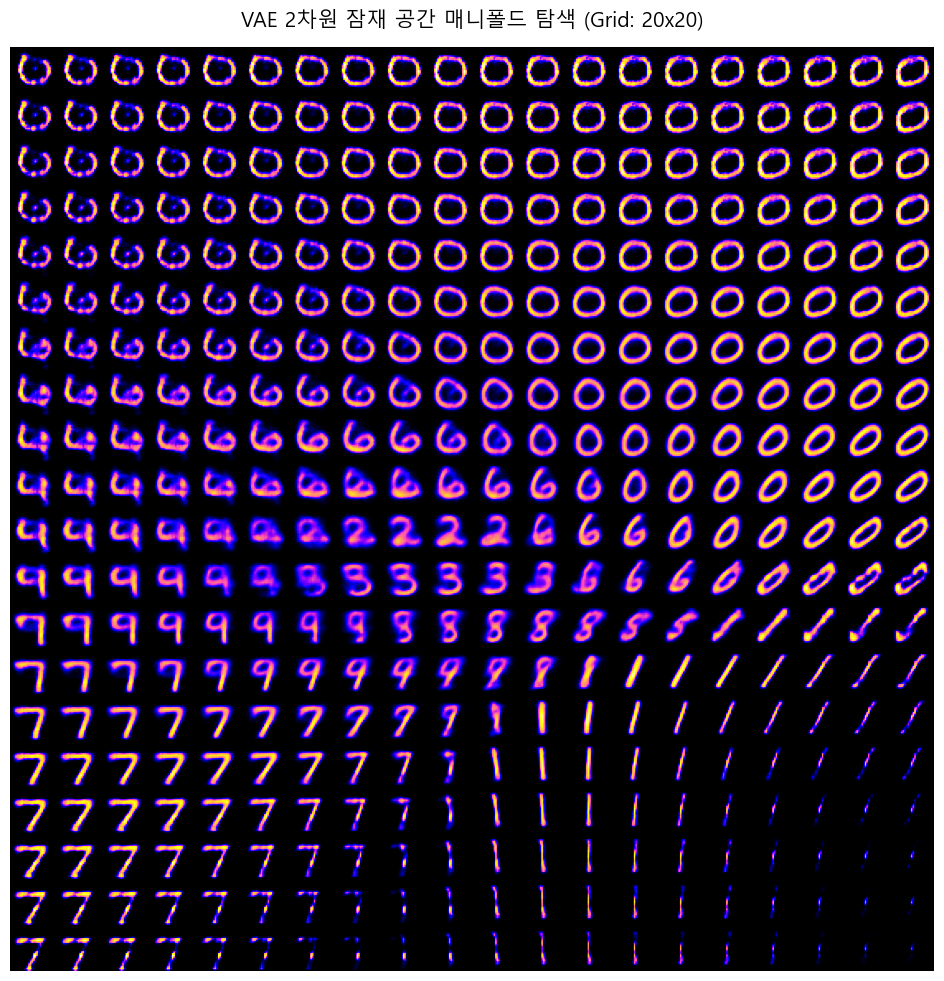

In [12]:
# 2D 잠재 공간 매니폴드 이미지 그리드 생성 함수
def plot_latent_manifold(decoder, n=20, figsize=12):
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    
    # z1, z2를 -3부터 3까지 균등하게 분할
    grid_x = np.linspace(-3.0, 3.0, n)
    grid_y = np.linspace(-3.0, 3.0, n)[::-1]  # 위에서 아래로 정렬

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure, cmap="gnuplot2")
    plt.axis("off")
    plt.title(f"VAE 2차원 잠재 공간 매니폴드 탐색 (Grid: {n}x{n})", fontsize=15, pad=15)
    plt.show()

# 매니폴드 생성 시각화 실행
plot_latent_manifold(vae.decoder, n=20)

## 7. 원본 이미지 vs VAE 복원 이미지 비교

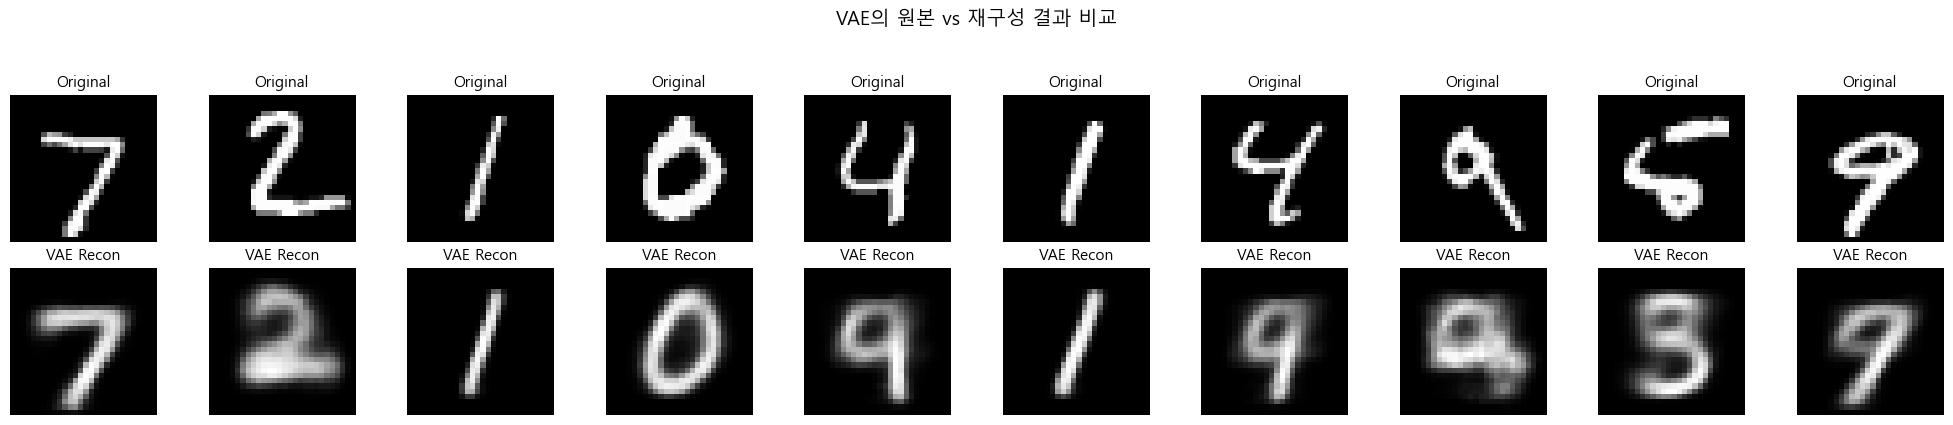

In [13]:
# 테스트 샘플 복원 확인
z_mean, _, z = vae.encoder.predict(x_test[:10], verbose=0)
reconstructed = vae.decoder.predict(z, verbose=0)

plt.figure(figsize=(20, 4))
for i in range(10):
    # 원본
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original", fontsize=11)
    plt.axis("off")

    # 복원
    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.title("VAE Recon", fontsize=11)
    plt.axis("off")

plt.suptitle("VAE의 원본 vs 재구성 결과 비교", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 8. 실습 요약 및 핵심 정리

1. **VAE의 생성 모델링 원리**:
   - 일반 오토인코더와 달리 잠재 변수를 확률 분포($\mu, \sigma^2$)로 매핑하고, 표준 정규분포 $\mathcal{N}(0, I)$로 정규화(KL Divergence)함으로써 **비어 있는 공간 없이 연속적이고 해석 가능한 잠재 공간**을 구축합니다.
2. **Reparameterization Trick**:
   - 확률적 샘플링의 비미분성 문제를 난수 변수 $\epsilon$의 선형 결합($z = \mu + \sigma \odot \epsilon$)으로 분리하여 엔드투엔드 역전파 학습을 가능하게 한 획기적인 기법입니다.
3. **생성 매니폴드의 가치**:
   - 2차원 잠재 평면 위의 임의의 좌표 $(z_1, z_2)$를 디코더에 통과시키는 것만으로 기존 데이터에 없던 새로운 손글씨 숫자를 무한히 생성할 수 있음을 매니폴드 그리드를 통해 검증했습니다.
4. **한계점과 다음 단계**:
   - VAE는 픽셀 평균 오차 기반 복원 특성상 다소 흐릿한(Blurry) 이미지가 생성될 수 있습니다. $\to$ 이는 보다 선명한 생성을 달성하는 **GAN(Lab 5-3)** 및 **Diffusion Model(Lab 5-4)** 실습으로 이어집니다.